# Lissajous and harmonograph curves

`biotuner.harmonic_geometry` ships closed-form Lissajous figures and damped
double-pendulum harmonographs. Both turn a ratio-set into a 2-D or 3-D
trajectory whose visual complexity is a direct expression of the input
harmonics — coprime ratios produce closed knots, near-rational ratios drift
through dense rosettes, and a small amount of damping makes the trace decay
inward like a real harmonograph drawing.

This notebook reproduces the Lissajous and harmonograph figures from the
`harmonic_geometry` report.


In [1]:
import warnings
from fractions import Fraction

import numpy as np
import matplotlib.pyplot as plt

from biotuner.harmonic_geometry import HarmonicInput, plotting

warnings.filterwarnings("ignore")
plt.rcParams["figure.dpi"] = 110


## Lissajous gallery — 2-D curves at different ratios

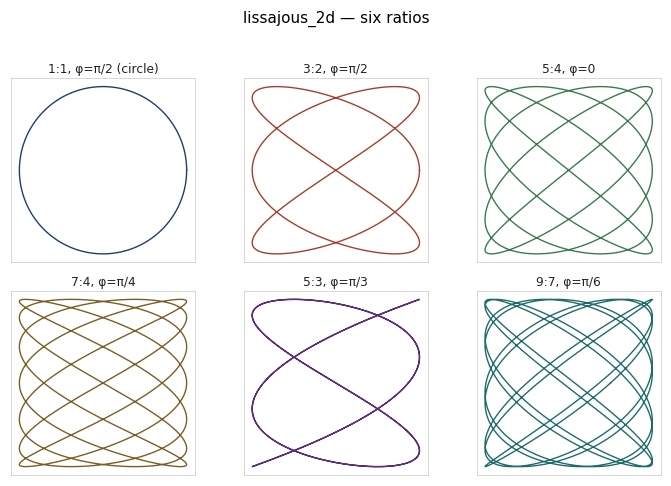

In [2]:
from biotuner.harmonic_geometry import lissajous_2d

cases = [
    (Fraction(1, 1),  np.pi/2, "1:1, φ=π/2 (circle)"),
    (Fraction(3, 2),  np.pi/2, "3:2, φ=π/2"),
    (Fraction(5, 4),  0.0,     "5:4, φ=0"),
    (Fraction(7, 4),  np.pi/4, "7:4, φ=π/4"),
    (Fraction(5, 3),  np.pi/3, "5:3, φ=π/3"),
    (Fraction(9, 7),  np.pi/6, "9:7, φ=π/6"),
]
geoms  = [lissajous_2d(r, phase=p, n_points=2000) for r, p, _ in cases]
titles = [lab for _, _, lab in cases]
plotting.gallery(geoms, titles=titles, n_cols=3,
                 suptitle="lissajous_2d — six ratios");


## 3-D Lissajous knots

When three coprime integer frequencies share a single trajectory the curve
closes into a knot — the spatial counterpart of a chord.

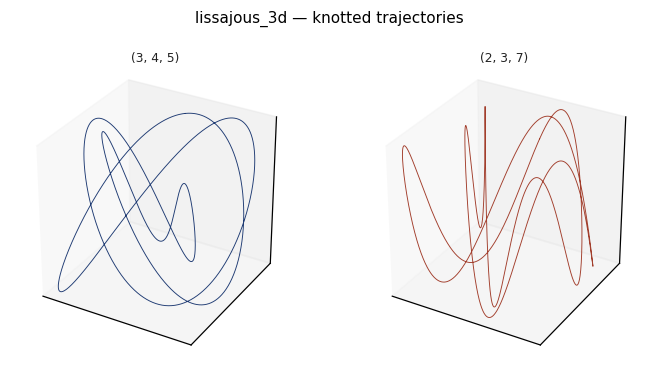

In [3]:
from biotuner.harmonic_geometry import lissajous_3d

geoms = [
    lissajous_3d(ratios=[3, 4, 5], phases=[0.0, np.pi/4, np.pi/2], n_points=4000),
    lissajous_3d(ratios=[2, 3, 7], phases=[0.0, np.pi/3, np.pi/5], n_points=4000),
]
plotting.gallery(geoms, titles=["(3, 4, 5)", "(2, 3, 7)"], n_cols=2,
                 suptitle="lissajous_3d — knotted trajectories");


## Pairwise grid and compound curves

`lissajous_pairwise_grid` traces every component pair of a chord, so the
diagonal contains 1:1 circles and off-diagonals encode interval structure.
`lissajous_compound` sums every component on each axis, giving a single
amplitude-weighted figure of the whole chord.

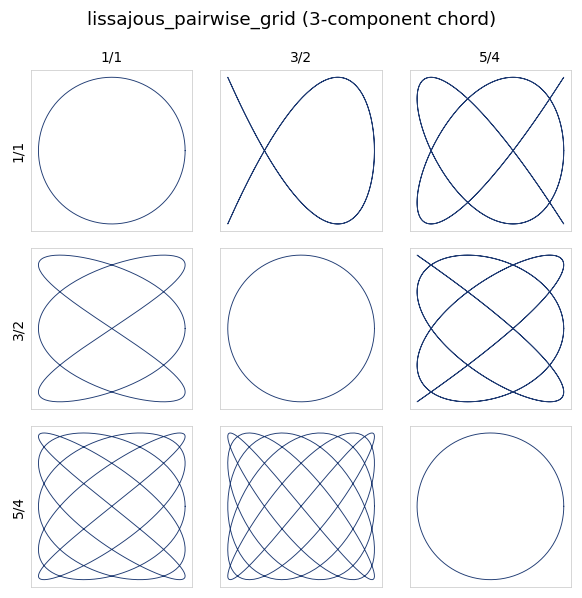

In [4]:
from biotuner.harmonic_geometry import lissajous_pairwise_grid, lissajous_compound

inp = HarmonicInput(ratios=[1, Fraction(3, 2), Fraction(5, 4)], base_freq=100.0)
grid = lissajous_pairwise_grid(inp, n_points=400)

labels = ["1/1", "3/2", "5/4"]
n = len(grid)
fig, axes = plt.subplots(n, n, figsize=(5.5, 5.5))
for i in range(n):
    for j in range(n):
        plotting.draw_curve_2d(grid[i][j], axes[i, j], lw=0.6)
        plotting.axis_clean(axes[i, j])
        axes[i, j].set_xticks([]); axes[i, j].set_yticks([])
        if i == 0: axes[i, j].set_title(labels[j], fontsize=9)
        if j == 0: axes[i, j].set_ylabel(labels[i], fontsize=9)
fig.suptitle("lissajous_pairwise_grid (3-component chord)")
fig.tight_layout();


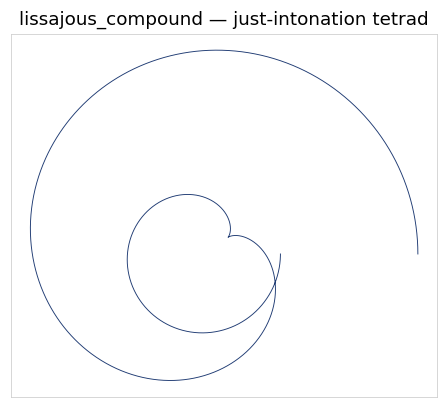

In [5]:
inp = HarmonicInput(
    ratios=[1, Fraction(3, 2), Fraction(5, 4), Fraction(7, 4)],
    amplitudes=[1.0, 0.7, 0.5, 0.3], base_freq=100.0,
)
g = lissajous_compound(inp, n_points=4000, n_periods=2)
fig, ax = plotting.plot_geometry(g, lw=0.6)
ax.set_title("lissajous_compound — just-intonation tetrad");


## Phase drift

A slowly-changing phase between two components un-closes a Lissajous figure
and lets it precess through every member of its family.

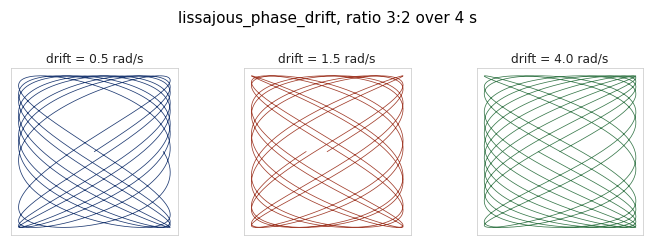

In [6]:
from biotuner.harmonic_geometry import lissajous_phase_drift

geoms = [
    lissajous_phase_drift(ratio=Fraction(3, 2), drift_rate=d, duration=4.0, sr=600)
    for d in (0.5, 1.5, 4.0)
]
plotting.gallery(geoms, titles=[f"drift = {d} rad/s" for d in (0.5, 1.5, 4.0)],
                 n_cols=3, suptitle="lissajous_phase_drift, ratio 3:2 over 4 s",
                 draw_kwargs={"lw": 0.5});


## Harmonograph examples

A real harmonograph couples two damped pendulums; `harmonograph_lateral`,
`harmonograph_rotary`, and `harmonograph_3d` cover the three common rigs.
Pass a `HarmonicInput` with `peaks` and per-component `damping` and the
trace will decay exactly as a physical apparatus does.

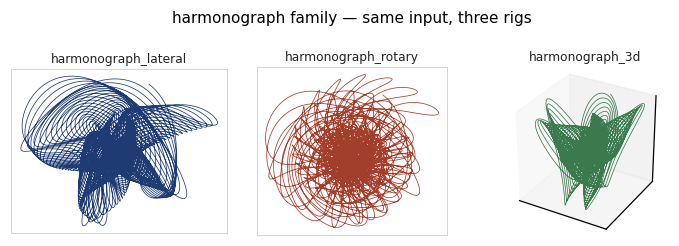

In [7]:
from biotuner.harmonic_geometry import (
    harmonograph_3d, harmonograph_lateral, harmonograph_rotary,
)

inp = HarmonicInput(
    peaks=[2.01, 3.02, 5.0, 7.03],
    amplitudes=[1.0, 0.8, 0.6, 0.4],
    phases=[0.0, np.pi/5, np.pi/3, np.pi/7],
    damping=[0.05, 0.04, 0.06, 0.05],
)
g_lat = harmonograph_lateral(inp, duration=40.0, sr=400)
g_rot = harmonograph_rotary(inp, duration=40.0, sr=400, rotation_freq=0.05)
g_3d  = harmonograph_3d(inp, duration=40.0, sr=400)

plotting.gallery([g_lat, g_rot, g_3d],
                 titles=["harmonograph_lateral", "harmonograph_rotary", "harmonograph_3d"],
                 n_cols=3, draw_kwargs={"lw": 0.5},
                 suptitle="harmonograph family — same input, three rigs");


## Effect of damping

Zero damping gives a bounded but persistent trace; even mild damping makes
the figure spiral inward to a point.

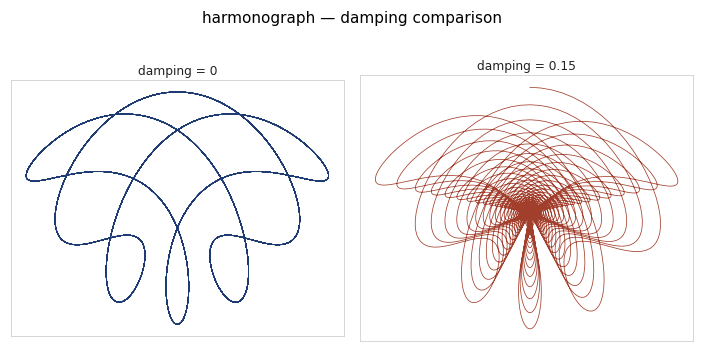

In [8]:
inp_zero  = HarmonicInput(peaks=[2.0, 3.0, 5.0, 7.0],
                          amplitudes=[1.0, 0.8, 0.6, 0.4],
                          damping=[0.0]*4)
inp_decay = HarmonicInput(peaks=[2.0, 3.0, 5.0, 7.0],
                          amplitudes=[1.0, 0.8, 0.6, 0.4],
                          damping=[0.15]*4)
geoms = [harmonograph_lateral(inp_zero,  duration=30.0, sr=300),
         harmonograph_lateral(inp_decay, duration=30.0, sr=300)]
plotting.gallery(geoms,
                 titles=["damping = 0", "damping = 0.15"],
                 n_cols=2, draw_kwargs={"lw": 0.5},
                 suptitle="harmonograph — damping comparison");
